Saving HR_comma_sep.csv to HR_comma_sep (1).csv
   satisfaction_level  last_evaluation  number_project  average_montly_hours  \
0                0.38             0.53               2                   157   
1                0.80             0.86               5                   262   
2                0.11             0.88               7                   272   
3                0.72             0.87               5                   223   
4                0.37             0.52               2                   159   

   time_spend_company  Work_accident  left  promotion_last_5years Department  \
0                   3              0     1                      0      sales   
1                   6              0     1                      0      sales   
2                   4              0     1                      0      sales   
3                   5              0     1                      0      sales   
4                   3              0     1                      0      

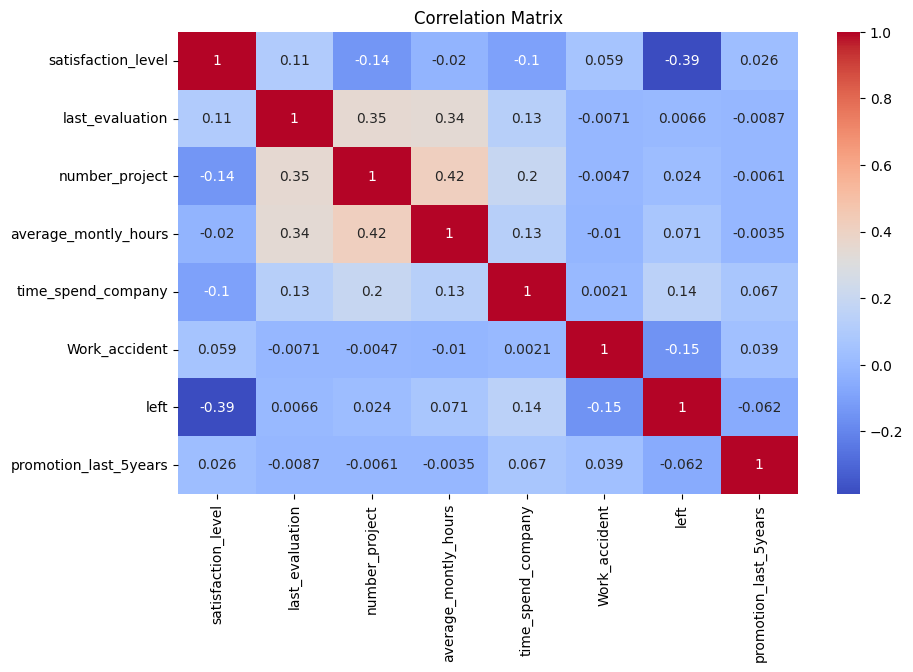

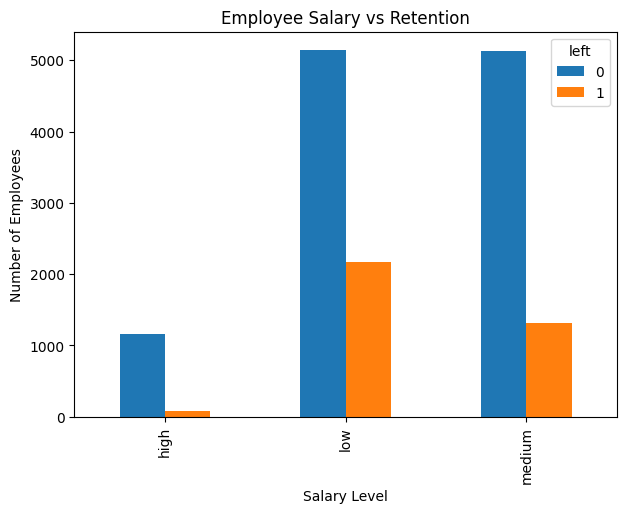

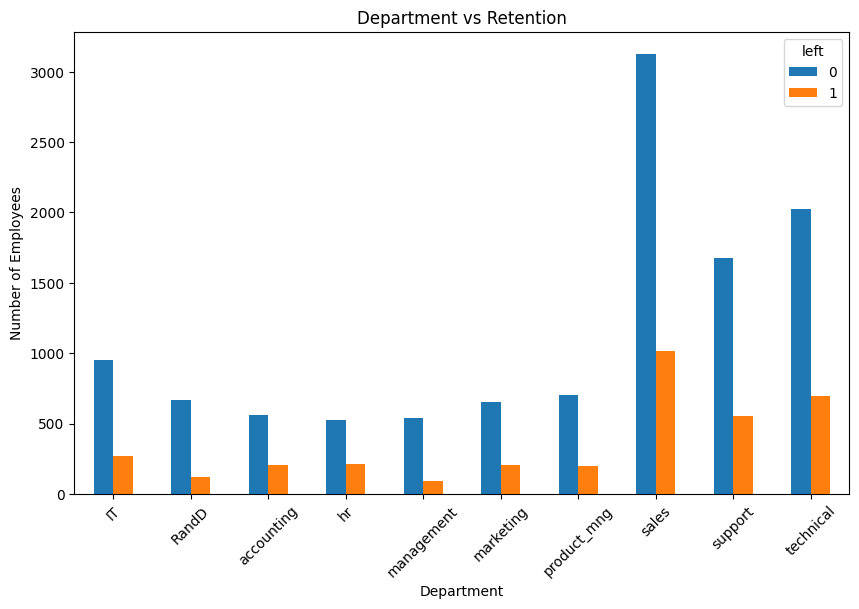

Model Accuracy: 0.7531111111111111

Confusion Matrix:
[[3125  303]
 [ 808  264]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.91      0.85      3428
           1       0.47      0.25      0.32      1072

    accuracy                           0.75      4500
   macro avg       0.63      0.58      0.59      4500
weighted avg       0.72      0.75      0.72      4500



In [ ]:
# ================================
# 1. Import Required Libraries
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from google.colab import files
uploaded = files.upload()
# ================================
# 2. Load Dataset
# ================================
df = pd.read_csv("HR_comma_sep.csv")

print(df.head())
print(df.info())
print(df.describe())

# ================================
# 3. Exploratory Data Analysis (EDA)
# ================================

# Correlation matrix (only numeric columns)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=['int64','float64']).corr(),
            annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

# ================================
# 4. Salary vs Retention (Bar Chart)
# ================================
salary_retention = pd.crosstab(df.salary, df.left)

salary_retention.plot(kind='bar', figsize=(7,5))
plt.title("Employee Salary vs Retention")
plt.xlabel("Salary Level")
plt.ylabel("Number of Employees")
plt.show()

# ================================
# 5. Department vs Retention (Bar Chart)
# ================================
dept_retention = pd.crosstab(df.Department, df.left)

dept_retention.plot(kind='bar', figsize=(10,6))
plt.title("Department vs Retention")
plt.xlabel("Department")
plt.ylabel("Number of Employees")
plt.xticks(rotation=45)
plt.show()

# ================================
# 6. Feature Selection
# (Based on EDA & correlation)
# ================================

# Convert categorical variables to dummy variables
df = pd.get_dummies(df, columns=["salary", "Department"], drop_first=True)

# Select important features (example based on common HR dataset results)
X = df[[
    'satisfaction_level',
    'average_montly_hours',
    'promotion_last_5years',
    'time_spend_company'
]]

y = df['left']

# ================================
# 7. Train-Test Split
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ================================
# 8. Build Logistic Regression Model
# ================================
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ================================
# 9. Predictions & Accuracy
# ================================
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))